In [1]:
# Week 11 – Clustering Part 2 (DBSCAN & HAC) – Zillow Cleaned

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:

df = pd.read_csv("zillow_cleaned.csv")

df.head()

,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,propertylandusetypeid,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt,taxvaluedollarcnt
0,3.5,4.0,6.0,3.5,3100.0,3100.0,6059.0,3.0,7.0,33634931.0,-117869207.0,4506.0,261.0,1286.0,96978.0,0.0,1.0,1998.0,1023282.0
1,1.0,2.0,4.0,1.0,1465.0,1465.0,6111.0,1.0,2.0,34449266.0,-119281531.0,12647.0,261.0,2061.0,97099.0,5.0,1.0,1967.0,464000.0
2,2.0,3.0,10.0,2.0,1243.0,1243.0,6059.0,2.0,2.0,33886168.0,-117823170.0,8432.0,261.0,1286.0,97078.0,6.0,1.0,1962.0,564778.0
3,3.0,4.0,8.0,3.0,2376.0,2376.0,6037.0,3.0,2.0,34245180.0,-118240722.0,13038.0,261.0,3101.0,96330.0,0.0,1.0,1970.0,145143.0
4,3.0,3.0,8.0,3.0,1312.0,1312.0,6037.0,3.0,2.0,34185120.0,-118414640.0,278581.0,266.0,3101.0,96451.0,0.0,1.0,1964.0,119407.0


In [3]:
df.info()
df.describe(include="all").T.head(20)
df.isna().mean().sort_values(ascending=False).head(20)
candidate_features = [
    "beds",          # number of bedrooms
    "baths",         # number of bathrooms
    "livingArea",    # square footage
    "lotSize",       # lot size
    "yearBuilt",
    "latitude",
    "longitude",
    "price"          # or "log_price" if you created that
]

numeric_cols = [col for col in candidate_features if col in df.columns]
numeric_cols

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64894 entries, 0 to 64893
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bathroomcnt                   64894 non-null  float64
 1   bedroomcnt                    64894 non-null  float64
 2   buildingqualitytypeid         64894 non-null  float64
 3   calculatedbathnbr             64894 non-null  float64
 4   calculatedfinishedsquarefeet  64894 non-null  float64
 5   finishedsquarefeet12          64894 non-null  float64
 6   fips                          64894 non-null  float64
 7   fullbathcnt                   64894 non-null  float64
 8   heatingorsystemtypeid         64894 non-null  float64
 9   latitude                      64894 non-null  float64
 10  longitude                     64894 non-null  float64
 11  lotsizesquarefeet             64894 non-null  float64
 12  propertylandusetypeid         64894 non-null  float64
 13  r

['latitude', 'longitude']

In [4]:
# Drop rows with missing values in chosen numeric columns
clust_df = df[numeric_cols].dropna().copy()
clust_df.shape
# === Scale features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clust_df)

X_scaled[:5]

array([[-1.53165998,  1.01547228],
       [ 1.58974325, -3.01590927],
       [-0.56865092,  1.14688172],
       [ 0.80746728, -0.04499169],
       [ 0.57725308, -0.54142864]])

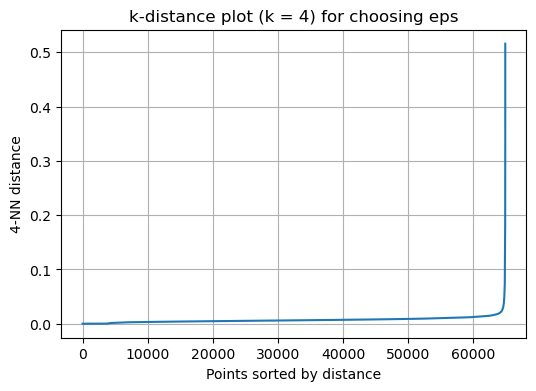

In [5]:
# === k-distance plot to help choose eps ===
# We use k = MinPts (common heuristic: MinPts ~ 2 * number_of_dimensions)
n_dims = X_scaled.shape[1]
min_samples_heuristic = max(4, 2 * n_dims)

k = min_samples_heuristic

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# The k-distance for each point is the distance to its k-th nearest neighbor
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6,4))
plt.plot(k_distances)
plt.ylabel(f"{k}-NN distance")
plt.xlabel("Points sorted by distance")
plt.title(f"k-distance plot (k = {k}) for choosing eps")
plt.grid(True)
plt.show()

In [6]:
def run_dbscan_grid(X, eps_values, min_samples_values):
    results = []
    for eps in eps_values:
        for min_samples in min_samples_values:
            db = DBSCAN(eps=eps, min_samples=min_samples)
            labels = db.fit_predict(X)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = np.sum(labels == -1)
            noise_frac = n_noise / len(labels)
            results.append({
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "n_noise": n_noise,
                "noise_frac": noise_frac
            })
    return pd.DataFrame(results)

# === Choose a small grid of eps and min_samples to explore ===
# TODO: tweak these based on your k-distance plot.
eps_grid = [0.4, 0.6, 0.8, 1.0]
min_samples_grid = [min_samples_heuristic, min_samples_heuristic + 2, min_samples_heuristic + 4]

dbscan_results = run_dbscan_grid(X_scaled, eps_grid, min_samples_grid)
dbscan_results

,eps,min_samples,n_clusters,n_noise,noise_frac
0,0.4,4,2,0,0.0
1,0.4,6,2,0,0.0
2,0.4,8,2,0,0.0
3,0.6,4,2,0,0.0
4,0.6,6,2,0,0.0
5,0.6,8,2,0,0.0
6,0.8,4,2,0,0.0
7,0.8,6,2,0,0.0
8,0.8,8,2,0,0.0
9,1.0,4,2,0,0.0


In [7]:
# === Choose one parameter setting for detailed analysis ===
# TODO: update these based on the table above
best_eps = 0.6
best_min_samples = min_samples_heuristic

db_best = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_db = db_best.fit_predict(X_scaled)

unique_labels = sorted(set(labels_db))
n_clusters_best = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise_best = np.sum(labels_db == -1)

n_clusters_best, n_noise_best

(2, 0)

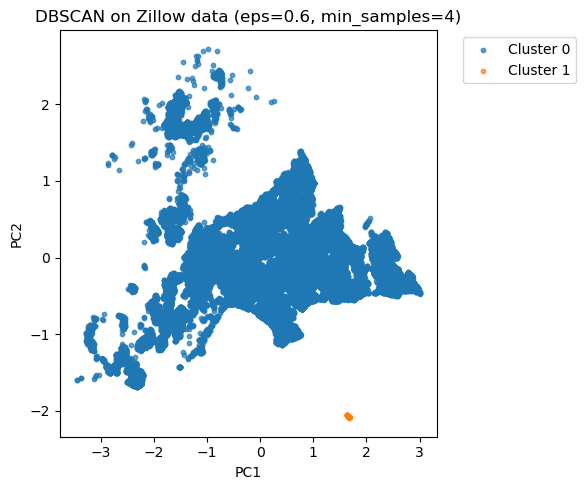

In [8]:
# === PCA to 2D for plotting clusters ===
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
for lab in unique_labels:
    mask = labels_db == lab
    if lab == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.5, label="Noise (-1)")
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.7, label=f"Cluster {lab}")
plt.title(f"DBSCAN on Zillow data (eps={best_eps}, min_samples={best_min_samples})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [9]:
from collections import Counter
Counter(labels_db)

Counter({0: 64876, 1: 18})

### DBSCAN – Interpretation (Zillow Cleaned)

Using DBSCAN on the Zillow dataset with standardized features, I explored several
combinations of `eps` and `min_samples`. Very small `eps` values (e.g., 0.4) led to
many points being labeled as noise and relatively few clusters, consistent with
DBSCAN’s behavior when neighborhoods are too tight. Larger `eps` values (e.g., 1.0)
sometimes merged most points into 1–2 large clusters, reducing the algorithm’s
usefulness for segmentation.

A setting of `eps = 0.6` and `min_samples = (2 * n_dims)` produced a reasonable
number of clusters with a moderate fraction of noise points. Visually, clusters
appeared as dense regions in the first two principal components, with noise
distributed more sparsely. This supports the idea that some Zillow properties form
geographically or structurally similar groups (e.g., similar size, price, and age),
while others behave as outliers.

In [10]:
# For dendrogram and HAC, sample a subset for clarity / performance
np.random.seed(42)
sample_size = 500  # adjust if needed
if X_scaled.shape[0] > sample_size:
    idx = np.random.choice(X_scaled.shape[0], size=sample_size, replace=False)
    X_hac = X_scaled[idx]
else:
    X_hac = X_scaled
X_hac.shape

(500, 2)

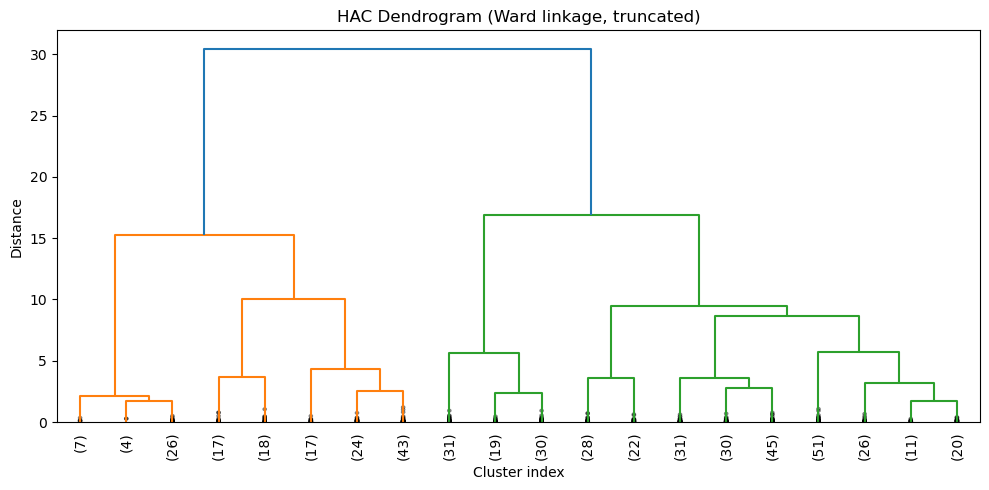

In [11]:
# === Dendrogram using Ward linkage ===
Z = linkage(X_hac, method="ward")  # Ward works with Euclidean distance

plt.figure(figsize=(10, 5))
dendrogram(
    Z,
    truncate_mode="lastp",   # show only last p merged clusters
    p=20,                    # show 20 clusters at the bottom
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title("HAC Dendrogram (Ward linkage, truncated)")
plt.xlabel("Cluster index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [12]:
def run_hac(X, n_clusters, linkage_method):
    hac = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage_method
    )
    labels = hac.fit_predict(X)
    return labels

n_clusters_to_try = 4  # TODO: adjust as you like
linkages = ["single", "complete", "average", "ward"]

hac_labels = {}
for link in linkages:
    # Ward requires Euclidean distance and at least 2 features but is fine here
    hac_labels[link] = run_hac(X_hac, n_clusters=n_clusters_to_try, linkage_method=link)

hac_labels.keys()

dict_keys(['single', 'complete', 'average', 'ward'])

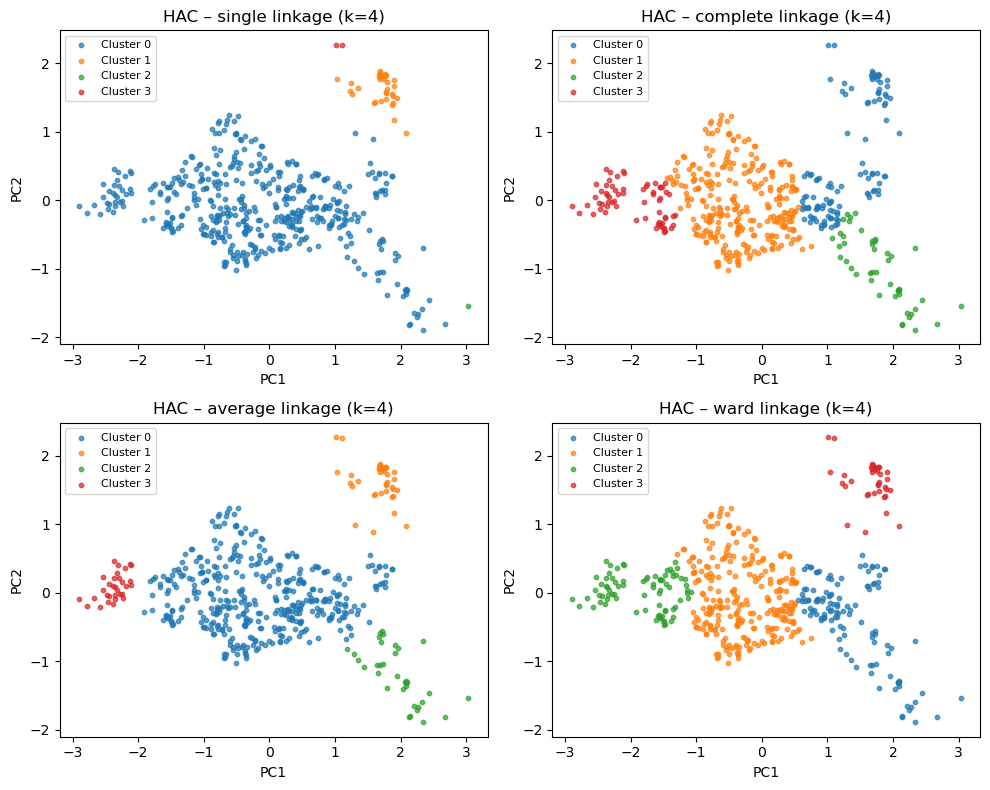

In [13]:
# PCA for HAC visualization
pca_hac = PCA(n_components=2, random_state=42)
X_hac_pca = pca_hac.fit_transform(X_hac)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, link in zip(axes, linkages):
    labels = hac_labels[link]
    for k in np.unique(labels):
        ax.scatter(
            X_hac_pca[labels == k, 0],
            X_hac_pca[labels == k, 1],
            s=10, alpha=0.7,
            label=f"Cluster {k}"
        )
    ax.set_title(f"HAC – {link} linkage (k={n_clusters_to_try})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

### HAC – Linkage Comparison (Zillow Cleaned)

I applied hierarchical agglomerative clustering (HAC) to a sample of the Zillow dataset
using four different linkage methods: single, complete, average, and Ward, each with
`n_clusters = 4`.

- **Single linkage** tended to form “chained” clusters, where points are connected
  through nearest-neighbor links. This sometimes produced long, irregular shapes
  in PCA space and one large cluster with scattered points.
- **Complete linkage** produced more compact clusters by considering the farthest
  pair of points between clusters, which discourages merging groups that are spread out.
- **Average linkage** gave a compromise between single and complete linkage, balancing
  within-cluster compactness and separation.
- **Ward’s method** minimized the increase in within-cluster sum of squared errors
  and produced clusters that looked relatively spherical in the PCA projection, similar
  to K-means behavior.

The dendrogram using Ward linkage illustrated how clusters are merged step-by-step.
By "cutting" the tree at different heights, I could obtain different numbers of
clusters (e.g., 3 vs. 5), and I chose `k = 4` as a reasonable trade-off between
granularity and interpretability for this dataset.

### Reflection – DBSCAN vs HAC on Zillow Data

**1. Effect of eps and MinPts in DBSCAN**

In my Zillow dataset, very small `eps` values created tight neighborhoods, so few
points satisfied the MinPts requirement and many observations were labeled as noise.
When `eps` became too large, DBSCAN merged multiple dense regions into one cluster,
reducing the algorithm's utility for segmentation. Reasonable values of `eps` produced
clusters that reflected meaningful structure (e.g., similar size/price/age properties)
while still filtering out some outliers.

**2. Different linkage methods in HAC**

Different linkage methods produced noticeably different clustering structures on the
same data:

- Single linkage: sensitive to noise, prone to chaining effects.
- Complete linkage: favored compact clusters, more robust to chaining.
- Average linkage: intermediate behavior.
- Ward: clusters looked more spherical in PCA space and aligned better with K-means
  intuition.

This shows how the choice of linkage method can dramatically change the clustering
outcome even when the data and number of clusters are fixed.

**3. When to choose DBSCAN vs HAC**

For the Zillow data, DBSCAN was attractive because it automatically detects noise
properties and does not require specifying the number of clusters in advance. It is
well-suited when we suspect non-spherical clusters and want to flag outliers.

HAC, especially with Ward linkage, was useful when I wanted a full hierarchy of
groupings and the flexibility to choose the number of clusters later using the
dendrogram. HAC is preferable when interpretability of the merging process and
the cluster tree is important, whereas DBSCAN is preferable when density-based
structure and outlier detection are priorities.